# Assignment Algorithm Simulation

Simulates the sequential bucket-based assignment algorithm for N users
without touching the database. Mirrors the logic in `assignments.py`.

In [1]:
import hashlib
import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# ---------- Constants (mirror assignments.py) ----------
SEED = 42
LESIONS_PER_USER = 101
MIN_ANNOTATORS = 3
MAX_ANNOTATORS = 5
NEED_MORE_CAP = 50

N_USERS = 30  # <-- change this to simulate different cohort sizes

In [2]:
# ---------- Core functions (copied from assignments.py, no Django deps) ----------

def _stable_hash(seed, *parts):
    blob = "|".join(str(p) for p in (seed, *parts))
    return int(hashlib.sha256(blob.encode()).hexdigest(), 16)


def get_eligible_lesions():
    json_path = Path("data/annotations_data.json")
    with open(json_path, "r", encoding="utf-8") as f:
        annotations_data = json.load(f)

    lesion_modes = defaultdict(set)
    for case_id in annotations_data:
        parts = case_id.rsplit("_", 1)
        if len(parts) == 2:
            lid, mode = parts
            lesion_modes[lid].add(mode)

    required = {"photo", "dscope", "combined"}
    return sorted(lid for lid, modes in lesion_modes.items()
                  if required.issubset(modes))


def select_lesions(user_id, eligible, counts, seed=SEED, n=LESIONS_PER_USER):
    need_more, fresh, saturated = [], [], []
    for lid in eligible:
        c = counts.get(lid, 0)
        if c == 0:
            fresh.append(lid)
        elif c < MIN_ANNOTATORS:
            need_more.append(lid)
        elif c < MAX_ANNOTATORS:
            saturated.append(lid)

    def _sort(bucket, tag):
        return sorted(bucket, key=lambda lid: _stable_hash(seed, tag, user_id, lid))

    need_more = _sort(need_more, "need_more")
    fresh = _sort(fresh, "fresh")
    saturated = _sort(saturated, "saturated")

    selected = []
    selected.extend(need_more[:min(len(need_more), NEED_MORE_CAP, n)])
    rem = n - len(selected)
    if rem > 0:
        selected.extend(fresh[:rem])
    rem = n - len(selected)
    if rem > 0:
        selected.extend(saturated[:rem])

    selected_set = set(selected)
    return [lid for lid in eligible if lid in selected_set]


eligible = get_eligible_lesions()
print(f"Eligible lesions: {len(eligible)}")

Eligible lesions: 1031


In [3]:
# ---------- Simulate sequential registration ----------

user_ids = [f"user_{i:03d}" for i in range(N_USERS)]

counts = Counter()           # lesion_id -> number of annotators
user_assignments = {}        # user_id -> [lesion_ids]
history = []                 # per-step snapshots for plotting

for uid in user_ids:
    lesions = select_lesions(uid, eligible, counts)
    user_assignments[uid] = lesions
    for lid in lesions:
        counts[lid] += 1

    # snapshot
    dist = Counter(counts.values())
    n_with_3plus = sum(cnt for k, cnt in dist.items() if k >= MIN_ANNOTATORS)
    n_dangling = sum(cnt for k, cnt in dist.items() if 1 <= k < MIN_ANNOTATORS)
    n_fresh = len(eligible) - sum(dist.values())
    history.append({
        "user": uid,
        "unique_covered": len(counts),
        "fresh_remaining": n_fresh,
        "dangling_1_2": n_dangling,
        "with_3plus": n_with_3plus,
        "dist": dict(dist),
    })

print(f"Simulated {N_USERS} users, {LESIONS_PER_USER} lesions each.")
print(f"Pool: {len(eligible)} eligible lesions.")

Simulated 30 users, 101 lesions each.
Pool: 1031 eligible lesions.


In [4]:
# ---------- Summary table ----------

print(f"{'User':>10}  {'Covered':>8}  {'Fresh left':>10}  {'Dangling(1-2)':>14}  {'3+ annot':>9}")
print("-" * 60)
for h in history:
    print(f"{h['user']:>10}  {h['unique_covered']:>8}  {h['fresh_remaining']:>10}  "
          f"{h['dangling_1_2']:>14}  {h['with_3plus']:>9}")

      User   Covered  Fresh left   Dangling(1-2)   3+ annot
------------------------------------------------------------
  user_000       101         930             101          0
  user_001       152         879             152          0
  user_002       203         828             185         18
  user_003       254         777             213         41
  user_004       305         726             247         58
  user_005       356         675             284         72
  user_006       407         624             320         87
  user_007       458         573             354        104
  user_008       509         522             381        128
  user_009       560         471             409        151
  user_010       611         420             437        174
  user_011       662         369             469        193
  user_012       713         318             496        217
  user_013       764         267             533        231
  user_014       815         216       

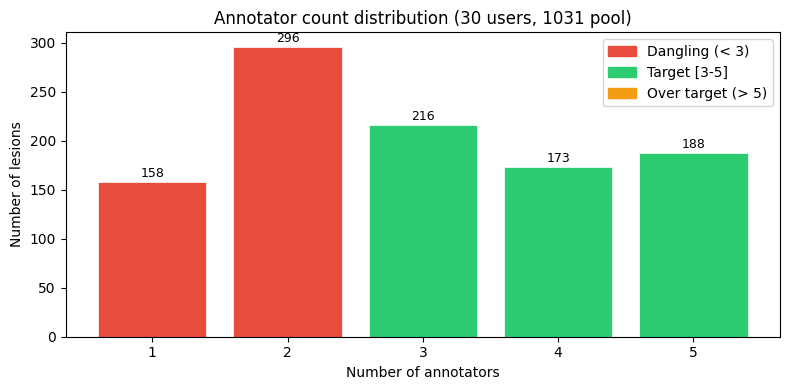


Untouched lesions (count=0): 0
  count=1: 158 lesions
  count=2: 296 lesions
  count=3: 216 lesions
  count=4: 173 lesions
  count=5: 188 lesions


In [5]:
# ---------- Final annotator count distribution ----------

final_dist = Counter(counts.values())
max_count = max(final_dist.keys())

xs = list(range(1, max_count + 1))
ys = [final_dist.get(x, 0) for x in xs]
colors = []
for x in xs:
    if x < MIN_ANNOTATORS:
        colors.append("#e74c3c")     # red = dangling
    elif x <= MAX_ANNOTATORS:
        colors.append("#2ecc71")     # green = target range
    else:
        colors.append("#f39c12")     # orange = over target

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(xs, ys, color=colors, edgecolor="white", linewidth=0.5)
for bar, y in zip(bars, ys):
    if y > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, y + 2, str(y),
                ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Number of annotators")
ax.set_ylabel("Number of lesions")
ax.set_title(f"Annotator count distribution ({N_USERS} users, {len(eligible)} pool)")
ax.set_xticks(xs)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#e74c3c", label=f"Dangling (< {MIN_ANNOTATORS})"),
    Patch(color="#2ecc71", label=f"Target [{MIN_ANNOTATORS}-{MAX_ANNOTATORS}]"),
    Patch(color="#f39c12", label=f"Over target (> {MAX_ANNOTATORS})"),
], loc="upper right")

plt.tight_layout()
plt.show()

n_untouched = len(eligible) - len(counts)
print(f"\nUntouched lesions (count=0): {n_untouched}")
for k in sorted(final_dist):
    print(f"  count={k}: {final_dist[k]} lesions")

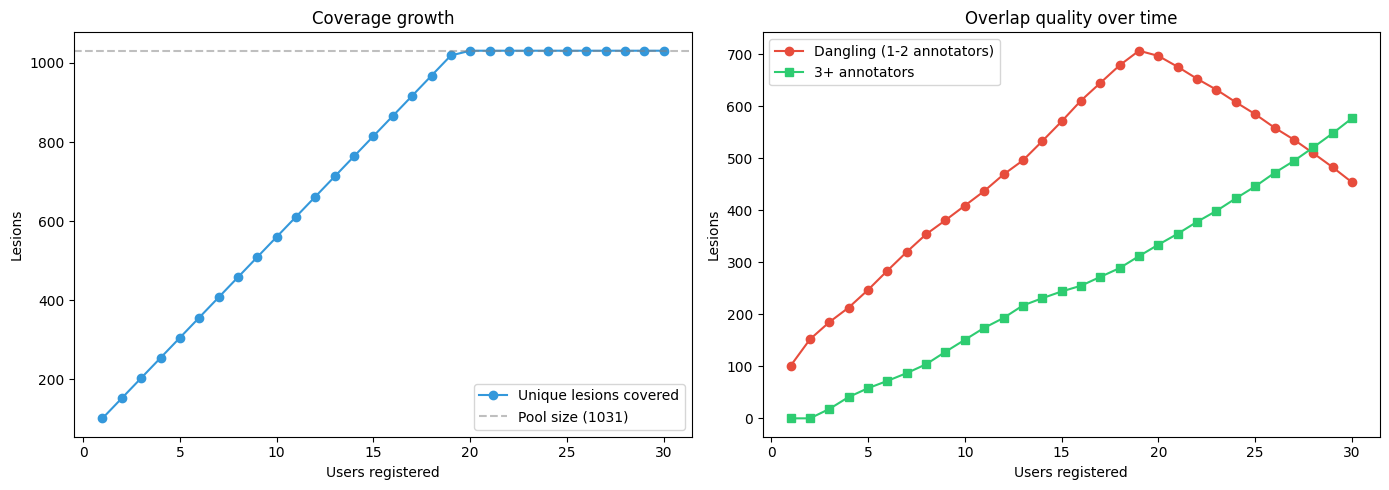

In [6]:
# ---------- Coverage & overlap over time ----------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xs = range(1, N_USERS + 1)

# Left: coverage
ax = axes[0]
ax.plot(xs, [h["unique_covered"] for h in history], "o-", label="Unique lesions covered", color="#3498db")
ax.axhline(len(eligible), color="gray", linestyle="--", alpha=0.5, label=f"Pool size ({len(eligible)})")
ax.set_xlabel("Users registered")
ax.set_ylabel("Lesions")
ax.set_title("Coverage growth")
ax.legend()

# Right: dangling vs 3+
ax = axes[1]
ax.plot(xs, [h["dangling_1_2"] for h in history], "o-", label="Dangling (1-2 annotators)", color="#e74c3c")
ax.plot(xs, [h["with_3plus"] for h in history], "s-", label="3+ annotators", color="#2ecc71")
ax.set_xlabel("Users registered")
ax.set_ylabel("Lesions")
ax.set_title("Overlap quality over time")
ax.legend()

plt.tight_layout()
plt.show()

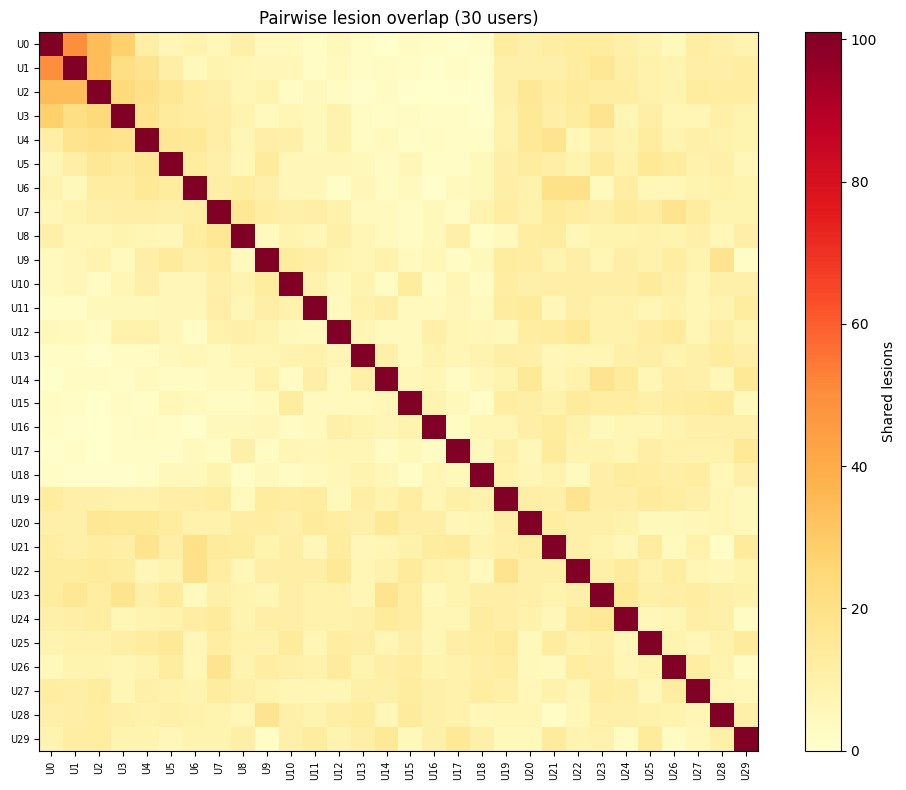

Pairwise overlap — min: 0, max: 50, mean: 8.9, median: 9


In [7]:
# ---------- Pairwise overlap heatmap ----------

n = len(user_ids)
overlap_matrix = np.zeros((n, n), dtype=int)
user_sets = {uid: set(lids) for uid, lids in user_assignments.items()}

for i, u1 in enumerate(user_ids):
    for j, u2 in enumerate(user_ids):
        overlap_matrix[i, j] = len(user_sets[u1] & user_sets[u2])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(overlap_matrix, cmap="YlOrRd", vmin=0)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f"U{i}" for i in range(n)], fontsize=7, rotation=90)
ax.set_yticklabels([f"U{i}" for i in range(n)], fontsize=7)
ax.set_title(f"Pairwise lesion overlap ({N_USERS} users)")
fig.colorbar(im, ax=ax, label="Shared lesions")
plt.tight_layout()
plt.show()

# Off-diagonal stats
off_diag = overlap_matrix[np.triu_indices(n, k=1)]
print(f"Pairwise overlap — min: {off_diag.min()}, max: {off_diag.max()}, "
      f"mean: {off_diag.mean():.1f}, median: {np.median(off_diag):.0f}")

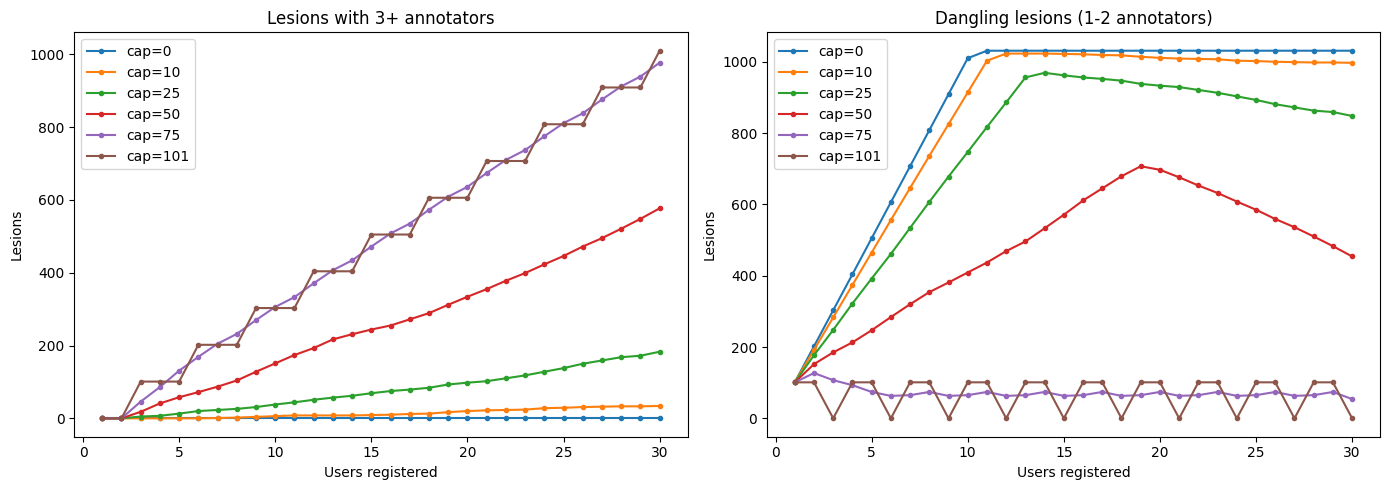

In [8]:
# ---------- Sensitivity: vary NEED_MORE_CAP ----------

caps_to_test = [0, 10, 25, 50, 75, 101]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cap in caps_to_test:
    cnts = Counter()
    hist_3plus = []
    hist_dangling = []

    for uid in user_ids:
        # Inline selection with variable cap
        nm, fr, sat = [], [], []
        for lid in eligible:
            c = cnts.get(lid, 0)
            if c == 0:
                fr.append(lid)
            elif c < MIN_ANNOTATORS:
                nm.append(lid)
            elif c < MAX_ANNOTATORS:
                sat.append(lid)

        nm.sort(key=lambda lid: _stable_hash(SEED, "need_more", uid, lid))
        fr.sort(key=lambda lid: _stable_hash(SEED, "fresh", uid, lid))
        sat.sort(key=lambda lid: _stable_hash(SEED, "saturated", uid, lid))

        sel = []
        sel.extend(nm[:min(len(nm), cap, LESIONS_PER_USER)])
        rem = LESIONS_PER_USER - len(sel)
        if rem > 0:
            sel.extend(fr[:rem])
        rem = LESIONS_PER_USER - len(sel)
        if rem > 0:
            sel.extend(sat[:rem])

        for lid in sel:
            cnts[lid] += 1

        d = Counter(cnts.values())
        hist_3plus.append(sum(v for k, v in d.items() if k >= MIN_ANNOTATORS))
        hist_dangling.append(sum(v for k, v in d.items() if 1 <= k < MIN_ANNOTATORS))

    axes[0].plot(range(1, N_USERS + 1), hist_3plus, "o-", markersize=3, label=f"cap={cap}")
    axes[1].plot(range(1, N_USERS + 1), hist_dangling, "o-", markersize=3, label=f"cap={cap}")

axes[0].set_title("Lesions with 3+ annotators")
axes[0].set_xlabel("Users registered")
axes[0].set_ylabel("Lesions")
axes[0].legend()

axes[1].set_title("Dangling lesions (1-2 annotators)")
axes[1].set_xlabel("Users registered")
axes[1].set_ylabel("Lesions")
axes[1].legend()

plt.tight_layout()
plt.show()